In [ ]:
import os

os.chdir("/home/jovyan/work")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: /home/jovyan/work


In [2]:
import os
os.environ['SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL'] = 'True'

# Install dl4ds after TensorFlow to ensure compatibility
!pip install dl4ds climetlab

# Uninstall standalone Keras 3 (it removes LocallyConnected2D)
!pip uninstall keras -y

# Install TensorFlow 2.15 with CUDA support (last version with Keras 2 bundled)
!pip install "tensorflow[and-cuda]==2.15.*"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of odclib to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 20.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 MB 59.8 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 42.2 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 40.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.7/574.7 kB 34.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 40.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 42.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import datetime
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import dl4ds as dds

# Reproducibility
np.random.seed(42)

2026-03-31 07:23:21.866790: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 07:23:21.909881: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-31 07:23:21.909898: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-31 07:23:21.910821: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-31 07:23:21.918748: I tensorflow/core/platform/cpu_feature_guar

In [4]:
ds = xr.open_dataset("data/era5_indonesia_2018-2022.zarr")
ds

<xarray.Dataset> Size: 4GB
Dimensions:                   (time: 7304, latitude: 181, longitude: 201)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 724B 30.0 29.75 ... -15.0
  * longitude                 (longitude) float32 804B 90.0 90.25 ... 140.0
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 1GB ...
    10m_v_component_of_wind   (time, latitude, longitude) float32 1GB ...
    2m_temperature            (time, latitude, longitude) float32 1GB ...
    total_precipitation_24hr  (time, latitude, longitude) float32 1GB ...

In [5]:
import numpy as np
import xarray as xr
import xesmf as xe

# =========================================
# Truth is the constraint — build LR from HR truth
# =========================================
scale = 6

ds_truth = ds.sortby("latitude")  # ensure south → north

tr_lons = ds_truth.longitude.values
tr_lats = ds_truth.latitude.values

# Pseudo-forecast grid from truth stride (Perfect Prognosis setup)
fc_lons = tr_lons[::scale]
fc_lats = tr_lats[::scale]

# ── Force start like forecast-correction notebook ──
lon_start = 90.0
lat_start = -13.5

# Snap to available pseudo-forecast coords
lon_start = float(fc_lons[np.argmin(np.abs(fc_lons - lon_start))])
lat_start = float(fc_lats[np.argmin(np.abs(fc_lats - lat_start))])

# ── Snap to truth grid indices ──
lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))

print(f"lon_start={lon_start}, idx={lon_start_idx}, truth={tr_lons[lon_start_idx]}")
print(f"lat_start={lat_start}, idx={lat_start_idx}, truth={tr_lats[lat_start_idx]}")

# ── Available truth points from start ──
avail_lon = len(tr_lons) - lon_start_idx
avail_lat = len(tr_lats) - lat_start_idx

# ── Max LR points truth can support ──
max_fc_lon = avail_lon // scale
max_fc_lat = avail_lat // scale

# ── Clamp to U-Net friendly size (24×32) ──
max_fc_lon = min(max_fc_lon, 32)
max_fc_lat = min(max_fc_lat, 24)

# ── Slice truth by exact count (HR target) ──
ds_tr = ds_truth.isel(
    longitude=slice(lon_start_idx, lon_start_idx + max_fc_lon * scale),
    latitude=slice(lat_start_idx, lat_start_idx + max_fc_lat * scale),
)
HIGH_LON = len(ds_tr.longitude)
HIGH_LAT = len(ds_tr.latitude)

# ── Build LR grid from HR stride ──
lr_lons = ds_tr.longitude.values[::scale]
lr_lats = ds_tr.latitude.values[::scale]

ds_lr_grid = xr.Dataset(
    coords={
        "lat": ("lat", lr_lats),
        "lon": ("lon", lr_lons),
    }
)

# ── Regrid HR -> LR with xESMF ──
ds_hr_in = ds_tr.rename({"latitude": "lat", "longitude": "lon"})
regridder_hr2lr = xe.Regridder(
    ds_hr_in,
    ds_lr_grid,
    method="bilinear",
    periodic=False,
    reuse_weights=False,
)
ds_fc = regridder_hr2lr(ds_hr_in, keep_attrs=True).rename({"lat": "latitude", "lon": "longitude"})

LOW_LON = len(ds_fc.longitude)
LOW_LAT = len(ds_fc.latitude)

print(f"\nForecast domain : lon {ds_fc.longitude.values[0]:.2f}→{ds_fc.longitude.values[-1]:.2f}"
      f"  lat {ds_fc.latitude.values[0]:.2f}→{ds_fc.latitude.values[-1]:.2f}")
print(f"Truth domain    : lon {ds_tr.longitude.values[0]:.2f}→{ds_tr.longitude.values[-1]:.2f}"
      f"  lat {ds_tr.latitude.values[0]:.2f}→{ds_tr.latitude.values[-1]:.2f}")
print(f"\nFinal forecast grid : {LOW_LAT} lat × {LOW_LON} lon")
print(f"Final truth grid    : {HIGH_LAT} lat × {HIGH_LON} lon")
print(f"Scale lon           : {HIGH_LON / LOW_LON:.6f}")
print(f"Scale lat           : {HIGH_LAT / LOW_LAT:.6f}")

lon_ok = np.allclose(ds_tr.longitude.values[::scale], ds_fc.longitude.values, atol=1e-8)
lat_ok = np.allclose(ds_tr.latitude.values[::scale],  ds_fc.latitude.values,  atol=1e-8)
print(f"Lons aligned        : {lon_ok}")
print(f"Lats aligned        : {lat_ok}")

if HIGH_LON == LOW_LON * scale and HIGH_LAT == LOW_LAT * scale and lon_ok and lat_ok:
    print(f"\n✅ Perfect {scale}× alignment!")
else:
    print(f"\n⚠ Still broken.")

# Keep names expected by your next cells
ds_pp_lr = ds_fc
ds_pp_hr = ds_tr

lon_start=90.0, idx=0, truth=90.0
lat_start=-13.5, idx=6, truth=-13.5

Forecast domain : lon 90.00→136.50  lat -13.50→21.00
Truth domain    : lon 90.00→137.75  lat -13.50→22.25

Final forecast grid : 24 lat × 32 lon
Final truth grid    : 144 lat × 192 lon
Scale lon           : 6.000000
Scale lat           : 6.000000
Lons aligned        : True
Lats aligned        : True

✅ Perfect 6× alignment!


In [6]:
ds_pp_lr

<xarray.Dataset> Size: 90MB
Dimensions:                   (time: 7304, latitude: 24, longitude: 32)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 96B -13.5 -12.0 ... 19.5 21.0
  * longitude                 (longitude) float32 128B 90.0 91.5 ... 135.0 136.5
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 22MB -6.866...
    10m_v_component_of_wind   (time, latitude, longitude) float32 22MB 3.512 ...
    2m_temperature            (time, latitude, longitude) float32 22MB 299.5 ...
    total_precipitation_24hr  (time, latitude, longitude) float32 22MB 0.0006...
Attributes:
    regrid_method:  bilinear

In [7]:
ds_pp_hr

<xarray.Dataset> Size: 3GB
Dimensions:                   (time: 7304, latitude: 144, longitude: 192)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 576B -13.5 -13.25 ... 22.25
  * longitude                 (longitude) float32 768B 90.0 90.25 ... 137.8
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 808MB ...
    10m_v_component_of_wind   (time, latitude, longitude) float32 808MB ...
    2m_temperature            (time, latitude, longitude) float32 808MB ...
    total_precipitation_24hr  (time, latitude, longitude) float32 808MB ...

In [8]:
import numpy as np

def check_nan_summary(ds, name):
    print(f"\n==== {name} ====")
    for var in ds.data_vars:
        data = ds[var].values
        total = data.size
        n_nan = np.isnan(data).sum()
        pct = (n_nan / total) * 100
        print(f"{var:30s} | NaNs: {n_nan:10d} | {pct:.5f}%")

check_nan_summary(ds_pp_lr, "Forecast (Low-res)")
check_nan_summary(ds_pp_hr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%


KeyboardInterrupt: 

In [ ]:
ds_pred = ds_pp_lr
ds_tar = ds_pp_hr

In [10]:
ARCH_PARAMS = dict(
    n_filters=36,          # Must be divisible by scale² (6²=36) for SPC upsampling
    n_blocks=8,
    normalization=None,    # Manual normalization below
    dropout_rate=0.0,
    dropout_variant='spatial',
    attention=False,
    activation='relu',
    localcon_layer=False   # Disabled - requires fixed spatial dimensions
)

# ==============================
# Per-variable training with MANUAL Z-SCORE NORMALIZATION
# DL4DS ResNet+SPC outputs 1 channel, so we train one model per variable
# ==============================

VAR_NAMES = list(ds_tar.data_vars)  # e.g. ['u10', 'v10', 't2m', 'tp']
trainers = {}
data = {}  # Initialize data dictionary to store test inputs/targets
norm_stats = {}  # Store normalization parameters (mean, std) for each variable

for i, var in enumerate(VAR_NAMES):
    print(f"\n{'='*60}")
    print(f"Training model for variable {i+1}/{len(VAR_NAMES)}: {var}")
    print(f"{'='*60}")

    # Extract single-channel data: (time, lat, lon, 1)
    target_var = ds_tar[[var]].to_array(dim='channel').transpose('time', 'latitude', 'longitude', 'channel')
    input_var  = ds_pred[[var]].to_array(dim='channel').transpose('time', 'latitude', 'longitude', 'channel')

    n_samples  = len(target_var.time)
    train_size = int(0.70 * n_samples)
    val_size   = int(0.15 * n_samples)
    
    # ══════════════════════════════════════════════════════════════
    # MANUAL Z-SCORE NORMALIZATION (compute stats from training data only)
    # ══════════════════════════════════════════════════════════════
    train_data = target_var.isel(time=slice(0, train_size)).values
    mean_val = np.nanmean(train_data)
    std_val  = np.nanstd(train_data)
    
    # Avoid division by zero for constant fields
    if std_val < 1e-8:
        std_val = 1.0
    
    norm_stats[var] = {'mean': mean_val, 'std': std_val}
    print(f"  Normalization: mean={mean_val:.4f}, std={std_val:.4f}")
    
    # Normalize all data
    target_var_norm = (target_var - mean_val) / std_val
    input_var_norm  = (input_var - mean_val) / std_val

    data_var = {
        'train_target': target_var_norm.isel(time=slice(0, train_size)),
        'val_target'  : target_var_norm.isel(time=slice(train_size, train_size + val_size)),
        'test_target' : target_var_norm.isel(time=slice(train_size + val_size, None)),
        'train_input' : input_var_norm.isel(time=slice(0, train_size)),
        'val_input'   : input_var_norm.isel(time=slice(train_size, train_size + val_size)),
        'test_input'  : input_var_norm.isel(time=slice(train_size + val_size, None)),
    }

    trainer = dds.SupervisedTrainer(
        backbone='resnet',
        upsampling='spc',

        data_train=data_var['train_target'],
        data_val  =data_var['val_target'],
        data_test =data_var['test_target'],

        data_train_lr=data_var['train_input'],
        data_val_lr  =data_var['val_input'],
        data_test_lr =data_var['test_input'],

        scale=6,
        time_window=None,
        static_vars=None,

        predictors_train=None,
        predictors_val  =None,
        predictors_test =None,

        interpolation='inter_area',
        patch_size=None,
        batch_size=64,
        loss='mae',
        epochs=100,
        steps_per_epoch=None,
        validation_steps=None,
        test_steps=None,
        learning_rate=(1e-3, 1e-4),
        lr_decay_after=1e4,
        early_stopping=True,
        patience=6,
        min_delta=0,
        save=False,
        save_path=None,
        show_plot=True,
        verbose=True,
        device='GPU',
        **ARCH_PARAMS
    )

    trainer.run()
    trainers[var] = trainer
    
    # Store NORMALIZED test data (for model input)
    data[f'test_input_{var}']  = data_var['test_input']
    data[f'test_target_{var}'] = data_var['test_target']
    
    # Store ORIGINAL test data (for evaluation metrics in original units)
    data[f'test_input_orig_{var}']  = input_var.isel(time=slice(train_size + val_size, None))
    data[f'test_target_orig_{var}'] = target_var.isel(time=slice(train_size + val_size, None))

print("\n✅ All variables trained successfully!")
print("\n📊 Normalization stats:")
for var, stats in norm_stats.items():
    print(f"  {var:<30} | mean={stats['mean']:>10.4f} | std={stats['std']:>10.4f}")



Training model for variable 1/4: 10m_u_component_of_wind
  Normalization: mean=-1.2018, std=4.0838


2026-03-14 12:44:40.275092: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-14 12:44:40.343494: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-14 12:44:40.345077: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

List of devices:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Number of devices: 1
Global batch size: 64
--------------------------------------------------------------------------------
Starting time: 2026-03-14 12:44:40
--------------------------------------------------------------------------------


L355
2026-03-14 12:44:40.481473: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-14 12:44:40.484888: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-14 12:44:40.487769: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43470 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:06:10.0, compute capability: 8.9


Model: "resnet_spc"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                Output Shape                                 Param #        Connected to                                 
 input_1 (InputLayer)                        [(None, None, None, 1)]                      0              []                                           
                                                                                                                                                      
 conv2d (Conv2D)                             (None, None, None, 36)                       360            ['input_1[0][0]']                            
                                                                                                                                                      
 ResidualBlock1 (ResidualBlock)              (None, None, None, 36)       

2026-03-14 12:44:45.068414: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-03-14 12:44:45.154773: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-14 12:44:45.468587: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-14 12:44:52.357570: I external/local_xla/xla/service/service.cc:168] XLA service 0x77caae859ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-14 12:44:52.357592: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX 6000 Ada Generation, Compute Capability 8.9
2026-03-14 12:44:52.361989: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773492292.443603    9184 device_co

79/79 [==============================] - 62s 351ms/step - loss: 0.2851 - val_loss: 0.1407
Epoch 2/100
79/79 [==============================] - 22s 274ms/step - loss: 0.1319 - val_loss: 0.1289
Epoch 3/100
79/79 [==============================] - 22s 276ms/step - loss: 0.1257 - val_loss: 0.1225
Epoch 4/100
79/79 [==============================] - 22s 278ms/step - loss: 0.1210 - val_loss: 0.1184
Epoch 5/100
79/79 [==============================] - 22s 281ms/step - loss: 0.1158 - val_loss: 0.1169
Epoch 6/100
79/79 [==============================] - 22s 279ms/step - loss: 0.1114 - val_loss: 0.1108
Epoch 7/100
79/79 [==============================] - 22s 279ms/step - loss: 0.1083 - val_loss: 0.1099
Epoch 8/100
79/79 [==============================] - 22s 279ms/step - loss: 0.1042 - val_loss: 0.1065
Epoch 9/100
79/79 [==============================] - 22s 280ms/step - loss: 0.1019 - val_loss: 0.1062
Epoch 10/100
79/79 [==============================] - 22s 279ms/step - loss: 0.0998 - val_loss

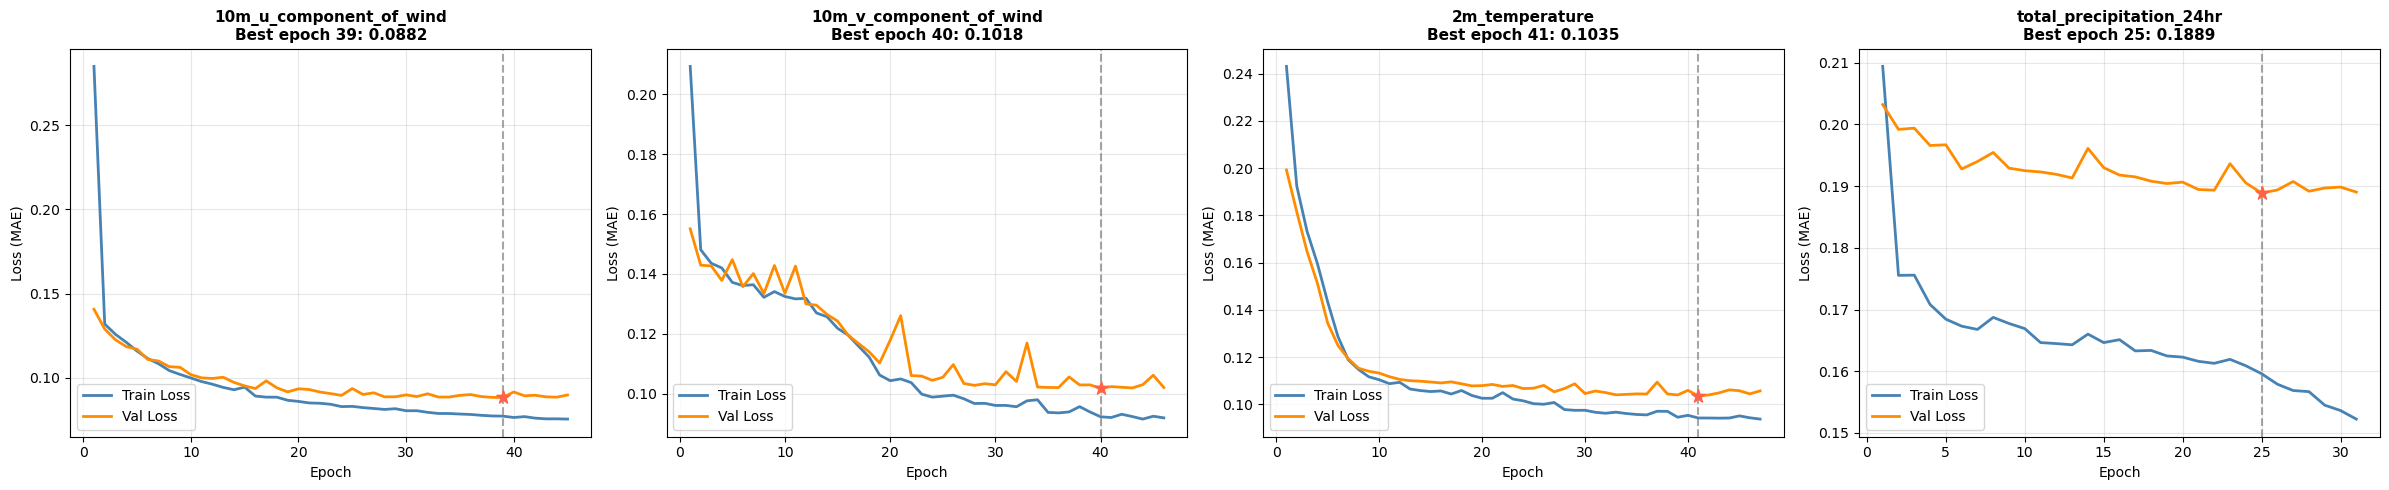

In [11]:
# ==============================
# PLOT TRAINING HISTORY (all variables)
# ==============================

VAR_LABELS_VIZ = list(ds_tar.data_vars)
fig, axes = plt.subplots(1, len(VAR_LABELS_VIZ), figsize=(6 * len(VAR_LABELS_VIZ), 5))

if len(VAR_LABELS_VIZ) == 1:
    axes = [axes]

for ax, var in zip(axes, VAR_LABELS_VIZ):
    history = trainers[var].fithist.history
    epochs_range = range(1, len(history["loss"]) + 1)
    ax.plot(epochs_range, history["loss"],     label="Train Loss",  linewidth=2, color="steelblue")
    ax.plot(epochs_range, history["val_loss"], label="Val Loss",    linewidth=2, color="darkorange")
    best_epoch = np.argmin(history["val_loss"]) + 1
    best_loss  = min(history["val_loss"])
    ax.axvline(best_epoch, color="gray", linestyle="--", alpha=0.7)
    ax.scatter([best_epoch], [best_loss], color="tomato", zorder=5, s=100, marker="*")
    ax.set_title(f"{var}\nBest epoch {best_epoch}: {best_loss:.4f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (MAE)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dl4ds_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
# ==============================
# EVALUATE MODEL ON TEST SAMPLE (per variable)
# ==============================

VAR_LABELS_VIZ = list(ds_tar.data_vars)
target_date = np.datetime64("2022-08-01")

FIELD_VMIN = [      -6,    -8,   285,   0.000]
FIELD_VMAX = [       6,     8,   302,   0.025]
ERROR_LIM  = [       4,     4,     5,   0.015]


test_times = ds_tar.time.values[int(0.85 * len(ds_tar.time)):]
idx = np.where(test_times == target_date)[0]

if len(idx) == 0:
    print(f"⚠️  {target_date} not found in test set.")
    print(f"Available range: {test_times[0]} → {test_times[-1]}")
    print(f"Using first test sample instead: {test_times[0]}")
    idx = 0
    target_date = test_times[0]
else:
    idx = idx[0]

print(f"Using date: {target_date}")
print(f"Test index: {idx}")

import tensorflow as tf

predictions = {}
for var in VAR_LABELS_VIZ:
    model = trainers[var].model
    
    # Use NORMALIZED data for model input
    X = data[f'test_input_{var}'].isel(time=idx).values       # (24, 32, 1) - normalized
    X_batch = np.expand_dims(X, axis=0)                        # (1, 24, 32, 1)
    Y_pred_norm  = model.predict(X_batch, verbose=0)[0]        # (144, 192, 1) - normalized
    
    # DENORMALIZE predictions back to original units
    mean_val = norm_stats[var]['mean']
    std_val  = norm_stats[var]['std']
    Y_pred = Y_pred_norm * std_val + mean_val                  # (144, 192, 1) - original units
    
    # Use ORIGINAL data for input and truth (for visualization)
    X_orig = data[f'test_input_orig_{var}'].isel(time=idx).values   # (24, 32, 1)
    Y_orig = data[f'test_target_orig_{var}'].isel(time=idx).values  # (144, 192, 1)
    
    predictions[var] = {
        'input': X_orig[:, :, 0],
        'pred' : Y_pred[:, :, 0],
        'truth': Y_orig[:, :, 0],
    }

print("\nPrediction shapes:")
for var, d in predictions.items():
    print(f"  {var}: input={d['input'].shape}, pred={d['pred'].shape}, truth={d['truth'].shape}")


Using date: 2022-08-01
Test index: 484

Prediction shapes:
  10m_u_component_of_wind: input=(24, 32), pred=(144, 192), truth=(144, 192)
  10m_v_component_of_wind: input=(24, 32), pred=(144, 192), truth=(144, 192)
  2m_temperature: input=(24, 32), pred=(144, 192), truth=(144, 192)
  total_precipitation_24hr: input=(24, 32), pred=(144, 192), truth=(144, 192)


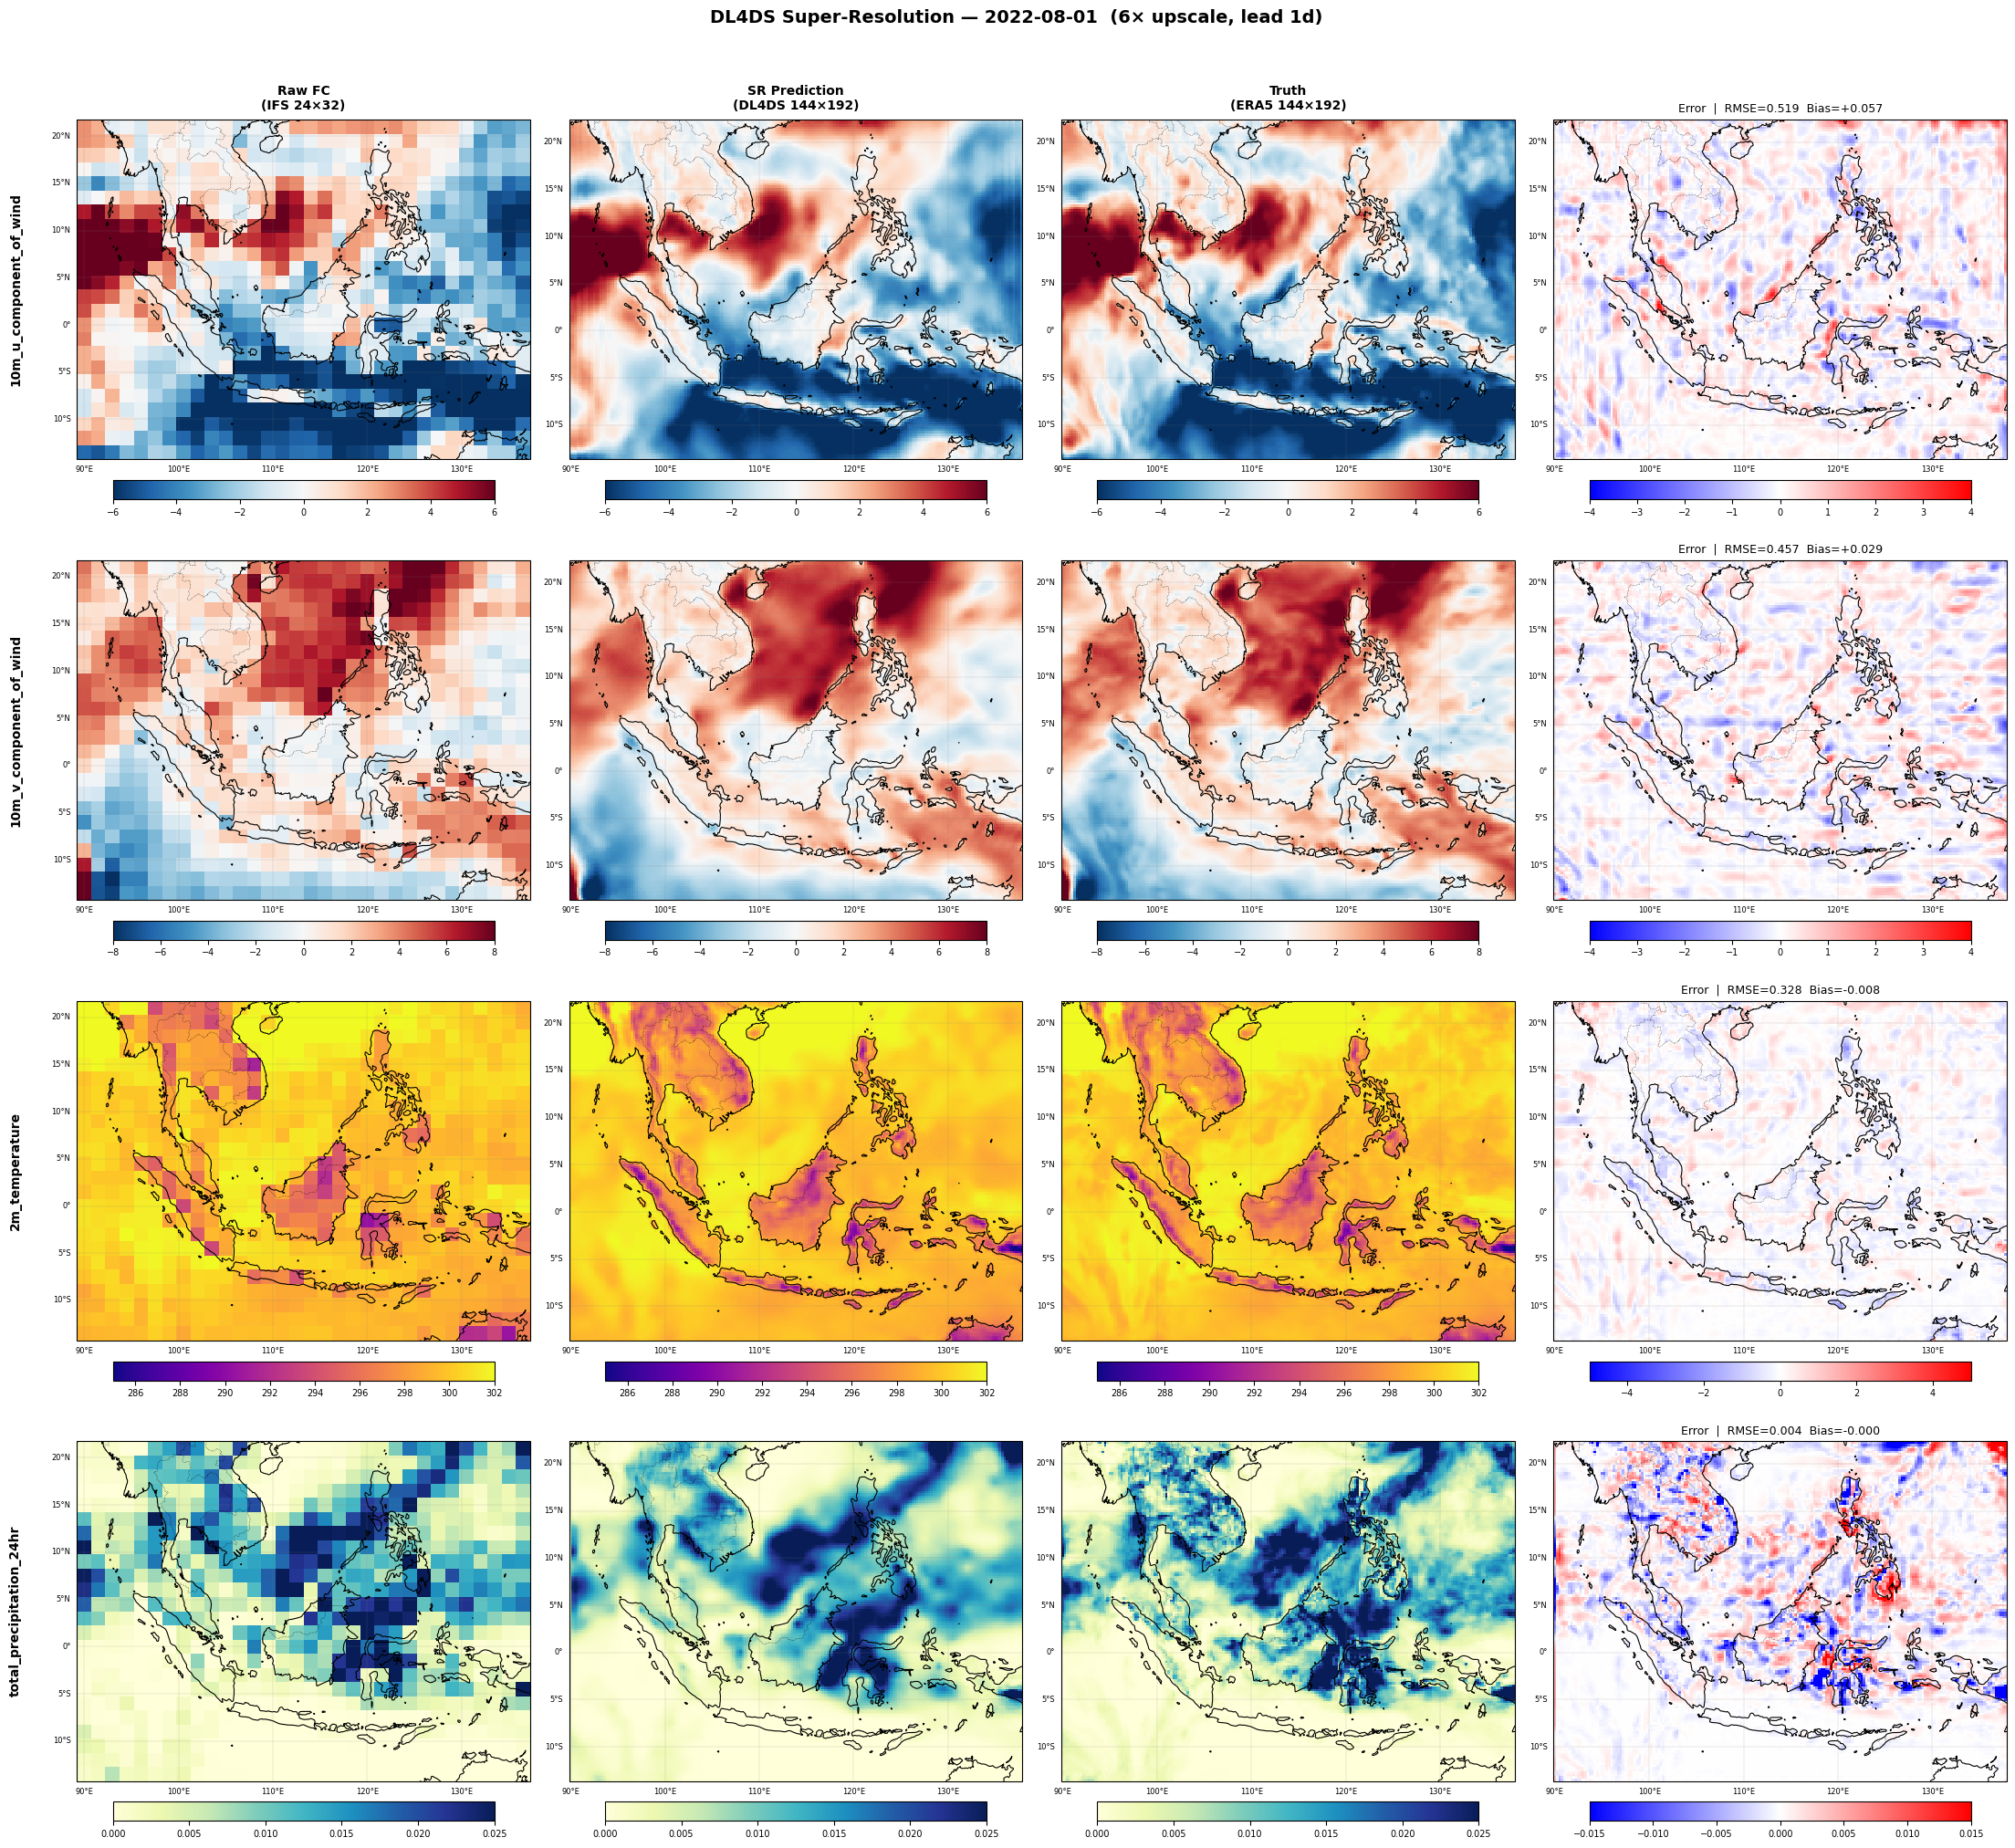


EVALUATION METRICS FOR 2022-08-01
10m_u_component_of_wind        | RMSE:   0.5193 | Bias:  +0.0572 | MAE:   0.3600
10m_v_component_of_wind        | RMSE:   0.4572 | Bias:  +0.0292 | MAE:   0.3255
2m_temperature                 | RMSE:   0.3278 | Bias:  -0.0084 | MAE:   0.2291
total_precipitation_24hr       | RMSE:   0.0042 | Bias:  -0.0003 | MAE:   0.0020


In [13]:
# ==============================
# VISUALIZE PREDICTIONS (per variable)
# ==============================

proj = ccrs.PlateCarree()
n_vars = len(VAR_LABELS_VIZ)

col_titles = [
    "Raw FC\n(IFS 24×32)",
    "SR Prediction\n(DL4DS 144×192)",
    "Truth\n(ERA5 144×192)",
    "Error\n(Pred - Truth)",
]

cmaps_field = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

lons_lr = ds_pred.longitude.values
lats_lr = ds_pred.latitude.values
lons_hr = ds_tar.longitude.values
lats_hr = ds_tar.latitude.values

fig, axes = plt.subplots(
    n_vars, 4,
    figsize=(22, 5 * n_vars),
    subplot_kw={"projection": proj},
)

for v, var_name in enumerate(VAR_LABELS_VIZ):
    raw_v  = predictions[var_name]['input']   # (24, 32)
    pred_v = predictions[var_name]['pred']    # (144, 192)
    true_v = predictions[var_name]['truth']   # (144, 192)
    err_v  = pred_v - true_v

    cmap_f = cmaps_field[v]
    vmin, vmax, elim = FIELD_VMIN[v], FIELD_VMAX[v], ERROR_LIM[v]

    panels = [
        (lons_lr, lats_lr, raw_v,  cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, pred_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, true_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, err_v,  "bwr",  -elim,  elim),
    ]

    for col, (lons, lats, field, cmap, lo, hi) in enumerate(panels):
        ax = axes[v, col]
        im = ax.pcolormesh(lons, lats, field, cmap=cmap, vmin=lo, vmax=hi,
                           shading="nearest", transform=proj)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=":")
        ax.add_feature(cfeature.LAND,      facecolor="whitesmoke", zorder=0)
        ax.add_feature(cfeature.OCEAN,     facecolor="lightcyan",  zorder=0)
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
        gl.top_labels   = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 6}
        gl.ylabel_style = {"size": 6}
        cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.046)
        cb.ax.tick_params(labelsize=7)
        if v == 0:
            ax.set_title(col_titles[col], fontsize=10, fontweight="bold", pad=8)
        if col == 0:
            ax.text(-0.15, 0.5, var_name, transform=ax.transAxes,
                    fontsize=10, fontweight="bold", va="center", rotation=90)

    rmse = np.sqrt(np.mean(err_v ** 2))
    bias = np.mean(err_v)
    axes[v, 3].set_title(f"Error  |  RMSE={rmse:.3f}  Bias={bias:+.3f}", fontsize=9, pad=6)

fig.suptitle(
    f"DL4DS Super-Resolution — {str(target_date)[:10]}  (6× upscale, lead 1d)",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(f"dl4ds_eval_{str(target_date)[:10]}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'='*60}")
print(f"EVALUATION METRICS FOR {str(target_date)[:10]}")
print(f"{'='*60}")
for v, var_name in enumerate(VAR_LABELS_VIZ):
    pred_v = predictions[var_name]['pred']
    true_v = predictions[var_name]['truth']
    err_v  = pred_v - true_v
    rmse = np.sqrt(np.mean(err_v ** 2))
    bias = np.mean(err_v)
    mae  = np.mean(np.abs(err_v))
    print(f"{var_name:30s} | RMSE: {rmse:8.4f} | Bias: {bias:+8.4f} | MAE: {mae:8.4f}")
print(f"{'='*60}")


In [14]:
# ==============================
# Aggregate test-set evaluation
# ==============================
from scipy.stats import pearsonr

VAR_LABELS_VIZ = list(ds_pp_lr.data_vars)

print("\n" + "=" * 100)
print(f"{'Variable':<24} | {'RMSE':>8} | {'MAE':>8} | {'Bias':>8} | {'Corr':>8} | {'Baseline RMSE':>14} | {'Skill':>8}")
print("=" * 100)

for var in VAR_LABELS_VIZ:
    model   = trainers[var].model
    n_test  = len(data[f'test_target_{var}'].time)
    
    # Get normalization stats for denormalization
    mean_val = norm_stats[var]['mean']
    std_val  = norm_stats[var]['std']

    pred_list, true_list, base_list = [], [], []

    for i in range(n_test):
        # NORMALIZED low-res input: (24, 32, 1)
        X_norm = data[f'test_input_{var}'].isel(time=i).values
        
        # ORIGINAL data for truth and baseline
        X_orig = data[f'test_input_orig_{var}'].isel(time=i).values
        Y_orig = data[f'test_target_orig_{var}'].isel(time=i).values  # (144, 192, 1)

        # Model prediction (normalized) → denormalize to original units
        X_batch = np.expand_dims(X_norm, axis=0)                      # (1, 24, 32, 1)
        Y_pred_norm = model.predict(X_batch, verbose=0)[0]            # (144, 192, 1) - normalized
        Y_pred = Y_pred_norm * std_val + mean_val                     # Denormalize to original units

        # Bilinear baseline: upsample ORIGINAL low-res to high-res
        import tensorflow as tf
        X_4d   = tf.constant(np.expand_dims(X_orig, axis=0))         # (1, 24, 32, 1)
        X_up   = tf.image.resize(X_4d, [144, 192], method='bilinear')[0].numpy()  # (144, 192, 1)

        pred_list.append(Y_pred[:, :, 0])
        true_list.append(Y_orig[:, :, 0])
        base_list.append(X_up[:, :, 0])

    # Keep sample + spatial structure: (N, H, W)
    pred_v = np.stack(pred_list, axis=0)
    true_v = np.stack(true_list, axis=0)
    base_v = np.stack(base_list, axis=0)

    # Remove NaNs without collapsing to 1D
    mask = ~(np.isnan(pred_v) | np.isnan(true_v) | np.isnan(base_v))
    pred_v = np.where(mask, pred_v, np.nan)
    true_v = np.where(mask, true_v, np.nan)
    base_v = np.where(mask, base_v, np.nan)

    # Model metrics: per-sample spatial metric, then averaged over test samples
    rmse = np.nanmean(np.sqrt(np.nanmean((pred_v - true_v) ** 2, axis=(1, 2))))
    mae  = np.nanmean(np.nanmean(np.abs(pred_v - true_v), axis=(1, 2)))
    bias = np.nanmean(np.nanmean(pred_v - true_v, axis=(1, 2)))

    # Correlation: spatial anomaly correlation per sample, then averaged
    p_mean = np.nanmean(pred_v, axis=(1, 2), keepdims=True)
    t_mean = np.nanmean(true_v, axis=(1, 2), keepdims=True)
    p_anom = pred_v - p_mean
    t_anom = true_v - t_mean
    num = np.nansum(p_anom * t_anom, axis=(1, 2))
    den = np.sqrt(np.nansum(p_anom ** 2, axis=(1, 2)) * np.nansum(t_anom ** 2, axis=(1, 2)))
    corr_per = np.divide(num, den, out=np.full_like(num, np.nan, dtype=np.float64), where=den > 0)
    corr = np.nanmean(corr_per)

    # Bilinear baseline RMSE (same aggregation as model RMSE)
    rmse_base = np.nanmean(np.sqrt(np.nanmean((base_v - true_v) ** 2, axis=(1, 2))))

    # Skill score: 1 - (RMSE_model / RMSE_baseline)
    skill = 1.0 - (rmse / rmse_base) if rmse_base > 0 else 0.0

    print(f"{var:<24} | {rmse:8.4f} | {mae:8.4f} | {bias:+8.4f} | {corr:8.4f} | {rmse_base:14.4f} | {skill:+8.4f}")

print("=" * 100)
print("\nSkill > 0 means DL4DS improves over bilinear interpolation baseline.")


Variable                 |     RMSE |      MAE |     Bias |     Corr |  Baseline RMSE |    Skill
10m_u_component_of_wind  |   0.5513 |   0.3716 |  +0.0634 |   0.9899 |         1.2515 |  +0.5595
10m_v_component_of_wind  |   0.5195 |   0.3487 |  +0.0141 |   0.9863 |         1.1078 |  +0.5310
2m_temperature           |   0.3784 |   0.2516 |  -0.0009 |   0.9842 |         1.2189 |  +0.6896
total_precipitation_24hr |   0.0051 |   0.0021 |  -0.0004 |   0.8956 |         0.0070 |  +0.2699

Skill > 0 means DL4DS improves over bilinear interpolation baseline.
